# MecaniQA - João Pessoa

Este notebook foca na organização dos dados de manutenção e na criação de modelos simples para entender o volume de serviços da MecaniQA entre 2024 e 2025.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

DATASET_PATH = Path('mecaniqa_dataset - mecaniqa_dataset.csv.csv')

if not DATASET_PATH.exists():
    DATASET_PATH = Path('/content') / DATASET_PATH.name

print(f'Dataset localizado em: {DATASET_PATH}')
assert DATASET_PATH.exists(), f'Arquivo não encontrado: {DATASET_PATH}'

def carregar_dataset(caminho: Path = DATASET_PATH) -> pd.DataFrame:
    dados = pd.read_csv(caminho, parse_dates=['Data'])
    dados = dados.set_index('Data').sort_index()
    dados.index.name = 'Data'
    return dados

dados = carregar_dataset()
dados.head()

Dataset localizado em: mecaniqa_dataset - mecaniqa_dataset.csv.csv


,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


## 1. Preparação e Carga

Usamos as bibliotecas padrão para manipular as tabelas (Pandas), gerar gráficos (Matplotlib) e decompor a série temporal (Statsmodels).

In [9]:
print('Primeiras linhas:')
display(dados.head())

print('\nInformações da base:')
dados.info()

print(f'\nDimensões: {dados.shape[0]} registros x {dados.shape[1]} atributos')
print(f'Período: {dados.index.min().date()} até {dados.index.max().date()}')
print(f'Atributos: {", ".join(dados.columns)}')

Primeiras linhas:


,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0



Informações da base:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2024-01-01 to 2025-12-31
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trocas_Oleo       725 non-null    float64
 1   Manutencao_Motor  728 non-null    float64
dtypes: float64(2)
memory usage: 17.1 KB

Dimensões: 731 registros x 2 atributos
Período: 2024-01-01 até 2025-12-31
Atributos: Trocas_Oleo, Manutencao_Motor


## 2. Visão Geral dos Dados

Verificação rápida da distribuição dos serviços e identificação de valores que ficaram em branco.

In [10]:
descricao = dados.describe()
display(descricao)

print('\nValores ausentes por coluna:')
print(dados.isna().sum())

print('\nSoma por coluna:')
print(dados.sum())

,Trocas_Oleo,Manutencao_Motor
count,725.000000,728.000000
mean,26.020690,10.179945
std,11.620655,5.419338
min,0.000000,-2.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,150.000000,85.000000



Valores ausentes por coluna:
Trocas_Oleo         6
Manutencao_Motor    3
dtype: int64

Soma por coluna:
Trocas_Oleo         18865.0
Manutencao_Motor     7411.0
dtype: float64


## 2.1 Ajuste de Picos (Outliers)

Identificamos valores que fogem muito do padrão e os limitamos para não distorcer as médias. Abaixo, aplicamos o ajuste e validamos visualmente a diferença entre o dado original e o tratado.

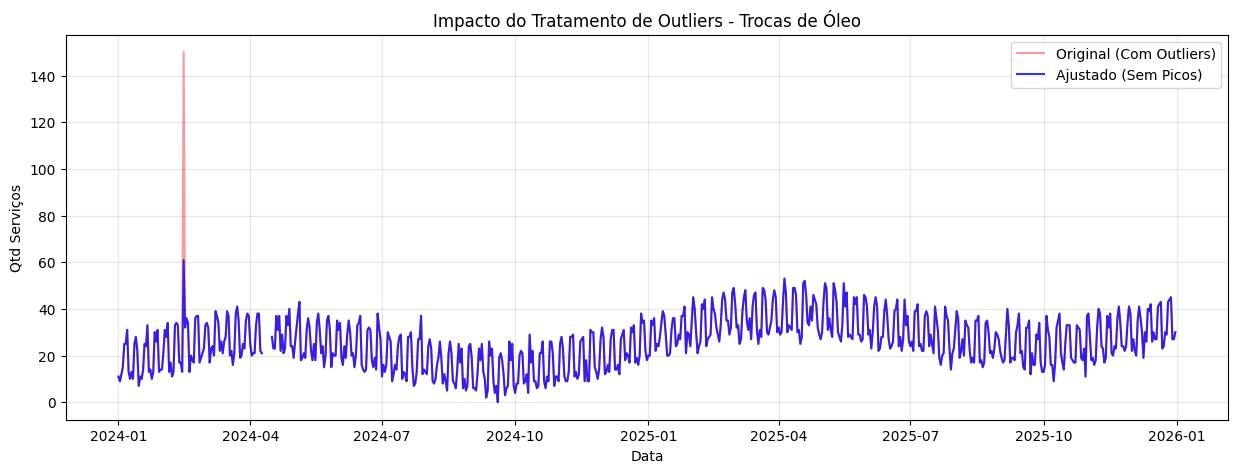

Picos extremos ajustados para o limite de 60.88


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Recarregar os dados originais do zero (sem tratamento prévio)
dados = pd.read_csv('mecaniqa_dataset - mecaniqa_dataset.csv.csv', parse_dates=['Data'])
dados = dados.set_index('Data').sort_index()

# 2. Cálculo do limite e tratamento
limite_superior = dados['Trocas_Oleo'].mean() + 3 * dados['Trocas_Oleo'].std()
dados['Trocas_Oleo_Original'] = dados['Trocas_Oleo'].copy()
dados['Trocas_Oleo'] = dados['Trocas_Oleo'].clip(upper=limite_superior)

# 3. Visualização Sobreposta
plt.figure(figsize=(15, 5))
plt.plot(dados['Trocas_Oleo_Original'], label='Original (Com Outliers)', color='red', alpha=0.4)
plt.plot(dados['Trocas_Oleo'], label='Ajustado (Sem Picos)', color='blue', alpha=0.8)

plt.title('Impacto do Tratamento de Outliers - Trocas de Óleo')
plt.xlabel('Data')
plt.ylabel('Qtd Serviços')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'Picos extremos ajustados para o limite de {limite_superior:.2f}')

## 3. Comportamento da Série

Separamos a demanda em tendência (direção do negócio) e sazonalidade (repetições semanais) para entender o ritmo da oficina.

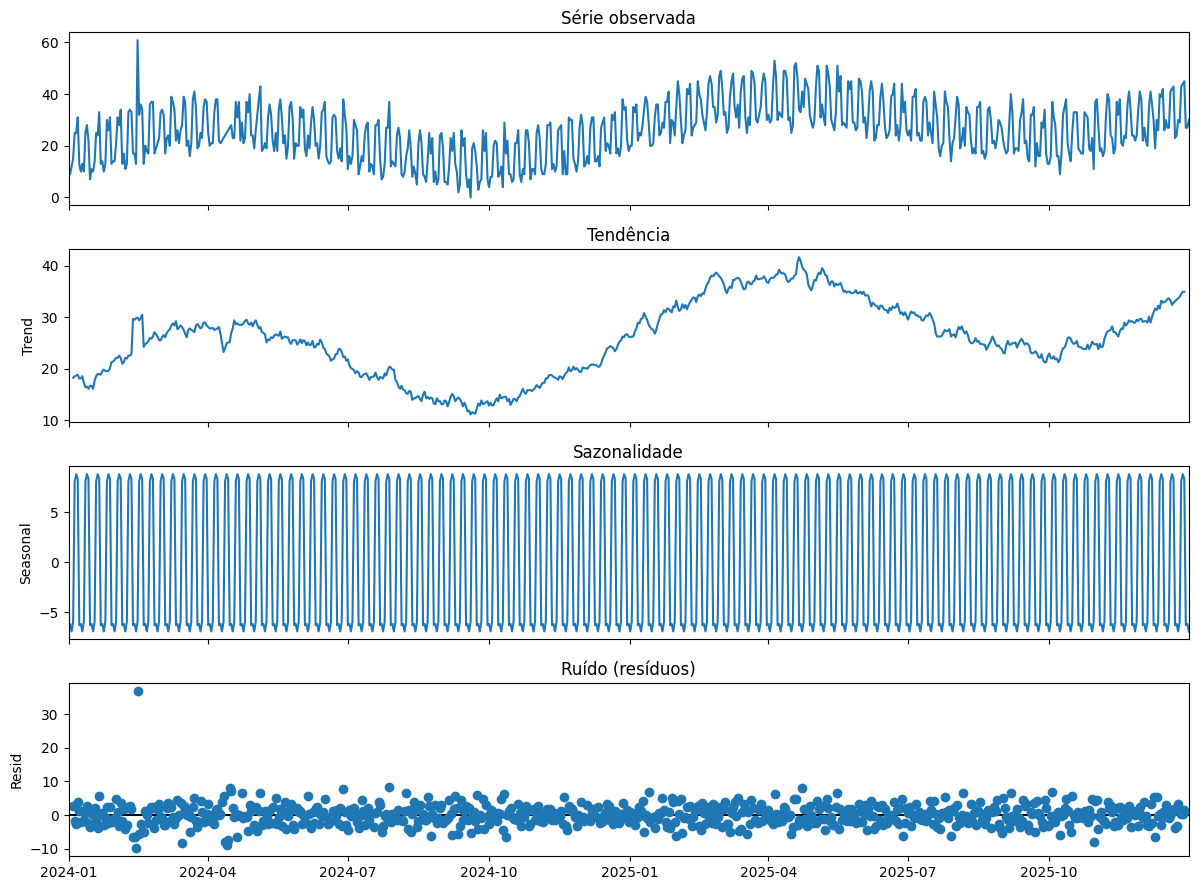


Resultado da decomposição:


Data
2024-01-01   -6.282664
2024-01-02   -6.161998
2024-01-03   -6.906797
2024-01-04   -5.930839
2024-01-05    8.096389
2024-01-06    8.821663
2024-01-07    8.364246
2024-01-08   -6.282664
2024-01-09   -6.161998
2024-01-10   -6.906797
Name: seasonal, dtype: float64

In [12]:
serie = dados['Trocas_Oleo'].interpolate(method='time')
resultado = seasonal_decompose(serie, model='additive', period=7)

figura = resultado.plot()
figura.set_size_inches(12, 9)
figura.axes[0].set_title('Série observada')
figura.axes[1].set_title('Tendência')
figura.axes[2].set_title('Sazonalidade')
figura.axes[3].set_title('Ruído (resíduos)')
figura.tight_layout()
plt.show()

print('\nResultado da decomposição:')
display(resultado.seasonal.head(10))

## 4. Modelos de Referência

Mantemos os três baselines da primeira entrega, sempre usando apenas informações disponíveis antes do dia previsto:
- **Ontem (Naive)**: repete o valor observado no dia anterior (`t-1`). É um dos modelos exigidos nesta etapa.
- **Média móvel de 7 dias**: calcula a média dos sete dias anteriores (`t-1` até `t-7`). É o segundo modelo exigido nesta etapa.
- **Média móvel de 30 dias**: baseline complementar da primeira entrega, também deslocada para usar somente os trinta dias anteriores (`t-1` até `t-30`).

In [34]:
# Preenchimento causal: usa apenas o último valor já conhecido, nunca valores futuros.
serie_limpa = dados['Trocas_Oleo'].ffill()


def previsao_naive(serie: pd.Series) -> pd.Series:
    """Prevê o valor de t usando exatamente o valor observado em t-1."""
    return serie.shift(1)


def previsao_media_movel(serie: pd.Series, janela: int = 7) -> pd.Series:
    """Prevê t com a média dos últimos `janela` valores, até t-1."""
    return serie.rolling(window=janela, min_periods=janela).mean().shift(1)


previsoes = pd.DataFrame(index=serie_limpa.index)
previsoes['Real'] = serie_limpa
previsoes['Naive'] = previsao_naive(serie_limpa)
previsoes['MM7'] = previsao_media_movel(serie_limpa, janela=7)
previsoes['MM30'] = previsao_media_movel(serie_limpa, janela=30)

# QA de vazamento: cada previsão em t só pode depender de valores anteriores a t.
assert previsoes['Naive'].equals(serie_limpa.shift(1))
assert previsoes['MM7'].equals(
    serie_limpa.rolling(window=7, min_periods=7).mean().shift(1)
)
assert previsoes['MM30'].equals(
    serie_limpa.rolling(window=30, min_periods=30).mean().shift(1)
)
assert previsoes['MM7'].iloc[7] == serie_limpa.iloc[:7].mean()
assert previsoes['MM30'].iloc[30] == serie_limpa.iloc[:30].mean()

print('QA de vazamento: aprovado. Nenhuma previsão usa o valor do próprio dia ou do futuro.')
display(previsoes.tail())

QA de vazamento: aprovado. Nenhuma previsão usa o valor do próprio dia ou do futuro.


,Real,Naive,MM7,MM30
Data,,,,
2025-12-27,44.0,43.0,33.428571,31.700000
2025-12-28,45.0,44.0,33.714286,32.366667
2025-12-29,27.0,45.0,34.000000,32.733333
2025-12-30,27.0,27.0,34.571429,32.266667
2025-12-31,30.0,27.0,35.000000,31.900000


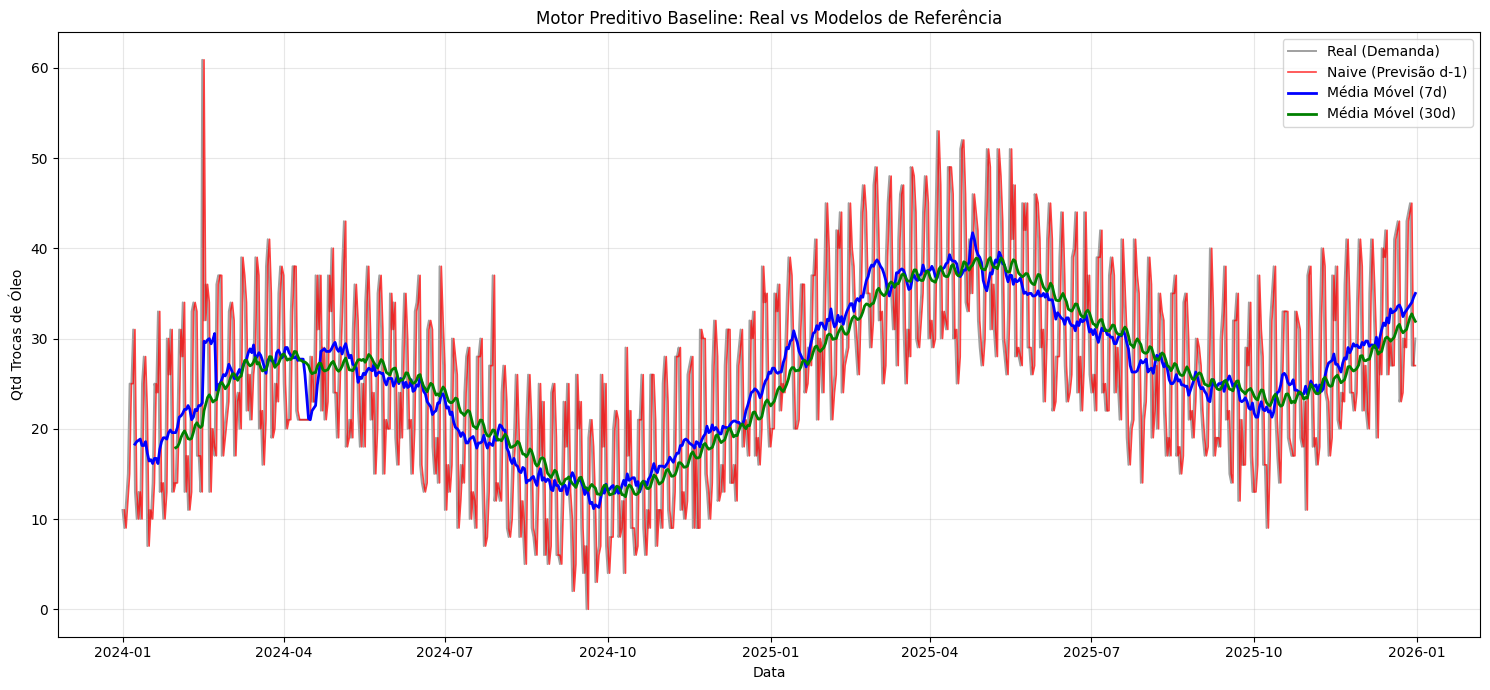

In [35]:
plt.figure(figsize=(15, 7))

plt.plot(
    previsoes['Real'],
    label='Real (Demanda)',
    color='#808080',
    linewidth=1.4,
    alpha=0.75,
    zorder=1,
)
plt.plot(
    previsoes['Naive'],
    label='Naive (Previsão d-1)',
    color='red',
    linewidth=1.2,
    alpha=0.75,
    zorder=2,
)
plt.plot(
    previsoes['MM7'],
    label='Média Móvel (7d)',
    color='blue',
    linewidth=2.0,
    zorder=3,
)
plt.plot(
    previsoes['MM30'],
    label='Média Móvel (30d)',
    color='green',
    linewidth=2.0,
    zorder=4,
)

plt.title('Motor Preditivo Baseline: Real vs Modelos de Referência')
plt.xlabel('Data')
plt.ylabel('Qtd Trocas de Óleo')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Resumo da Entrega Técnica

- **Saneamento:** dados limpos, com outliers tratados e lacunas preenchidas.
- **Modelagem:** Naive e Média Móvel de 7 dias implementados conforme o pedido atual; MM30 preservada como baseline complementar.
- **QA de causalidade:** asserts confirmam que Naive, MM7 e MM30 usam somente valores anteriores ao tempo `t`.
- **Visualização:** gráfico diário com histórico real em cinza, Naive em vermelho, MM7 em azul e MM30 em verde.